<a href="https://colab.research.google.com/github/saianusha10/SE-team-9-/blob/main/ML_1002227267.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Loading the necessary libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
from scipy.stats import zscore

# **1.i) Load the dataset and display the first few rows.**

In [ ]:
df = pd.read_excel('/content/loan_data.xlsx')
print(df.head()) # Display first few rows of the dataframe

   Age    Income  Credit_Score  Loan_Amount  Years_with_Bank  Num_of_Products  \
0   56   86788.0         617.0      48059.0               28                2   
1   69  107879.0           NaN      89078.0                7                4   
2   46   63827.0         681.0          NaN                1                1   
3   32  132188.0         532.0      66269.0               25                3   
4   60   30655.0         643.0      80986.0               11                4   

   Is_Employed Marital_Status Education_Level  Has_Credit_Card  Loan_Default  
0            1         Single        Bachelor                1             0  
1            1       Divorced             PhD                1             0  
2            1         Single     High School                1             0  
3            1       Divorced          Master                1             0  
4            1            NaN        Bachelor                0             0  


# **1. ii) Check for missing values and summarize the dataset.**

In [ ]:
print(df.isnull().sum())
print(df.info())

Age                  0
Income             150
Credit_Score       149
Loan_Amount        148
Years_with_Bank      0
Num_of_Products      0
Is_Employed          0
Marital_Status     150
Education_Level      0
Has_Credit_Card      0
Loan_Default         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              2000 non-null   int64  
 1   Income           1850 non-null   float64
 2   Credit_Score     1851 non-null   float64
 3   Loan_Amount      1852 non-null   float64
 4   Years_with_Bank  2000 non-null   int64  
 5   Num_of_Products  2000 non-null   int64  
 6   Is_Employed      2000 non-null   int64  
 7   Marital_Status   1850 non-null   object 
 8   Education_Level  2000 non-null   object 
 9   Has_Credit_Card  2000 non-null   int64  
 10  Loan_Default     2000 non-null   int64  
dtypes: float64(3), int64(6),

# **1. iii) Identify data types for each column.**

In [ ]:
df.dtypes # Identifying data types

,0
Age,int64
Income,float64
Credit_Score,float64
Loan_Amount,float64
Years_with_Bank,int64
Num_of_Products,int64
Is_Employed,int64
Marital_Status,object
Education_Level,object
Has_Credit_Card,int64


# iv. Analyze the distribution of numerical features (Income, Credit Score, Loan Amount

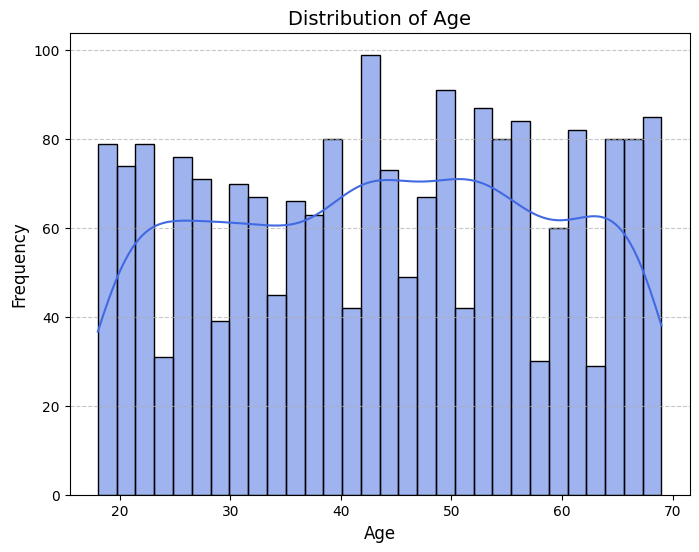

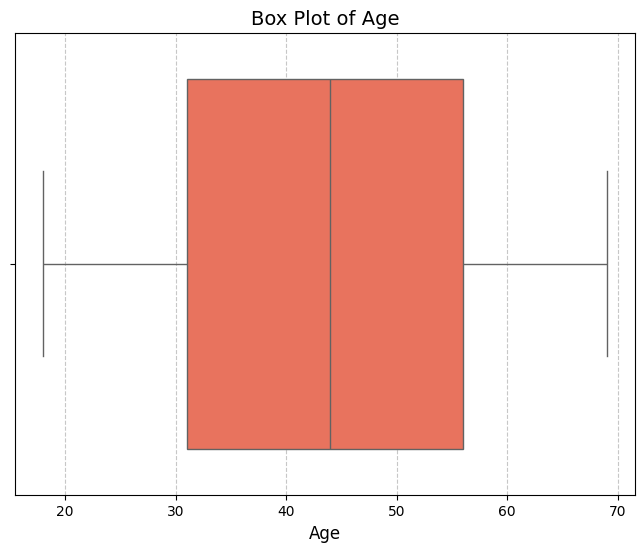

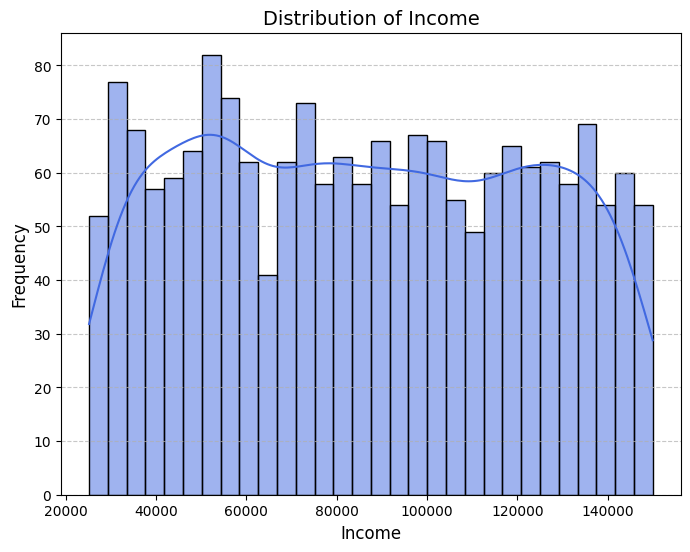

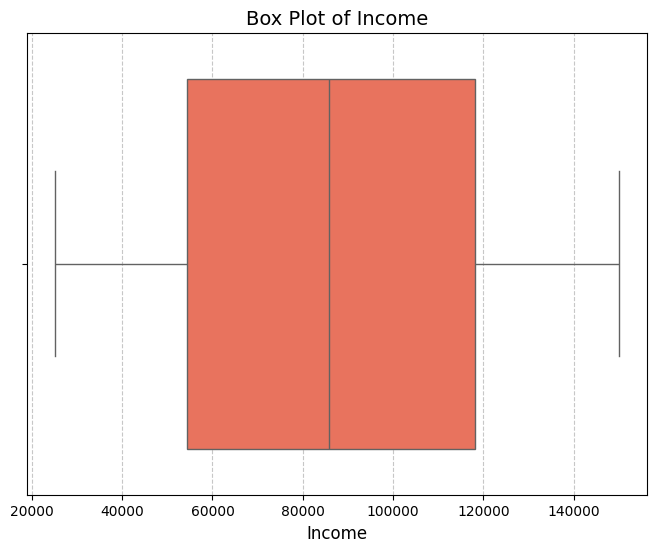

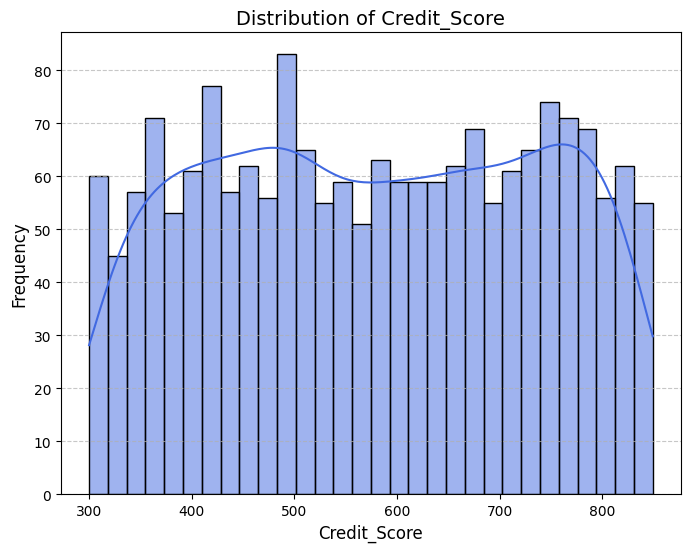

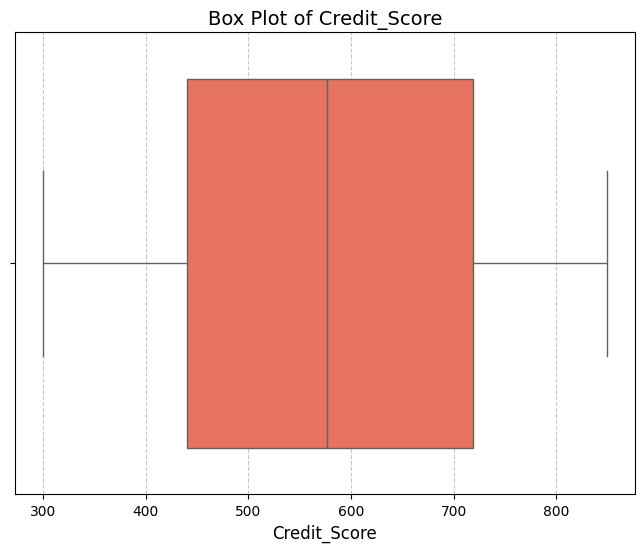

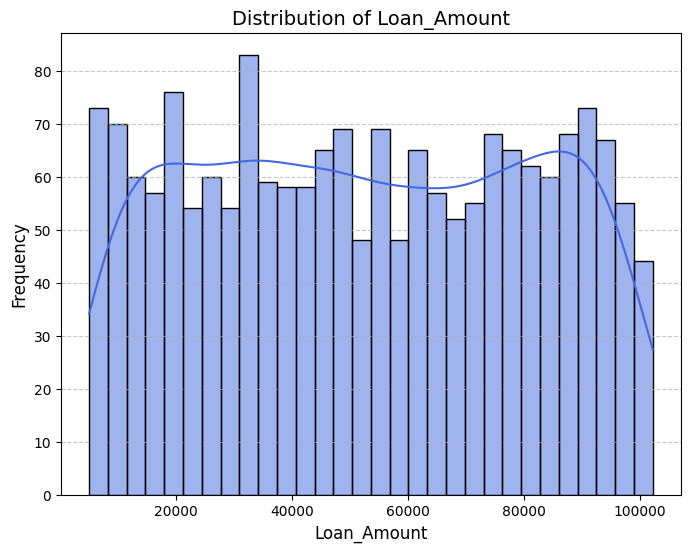

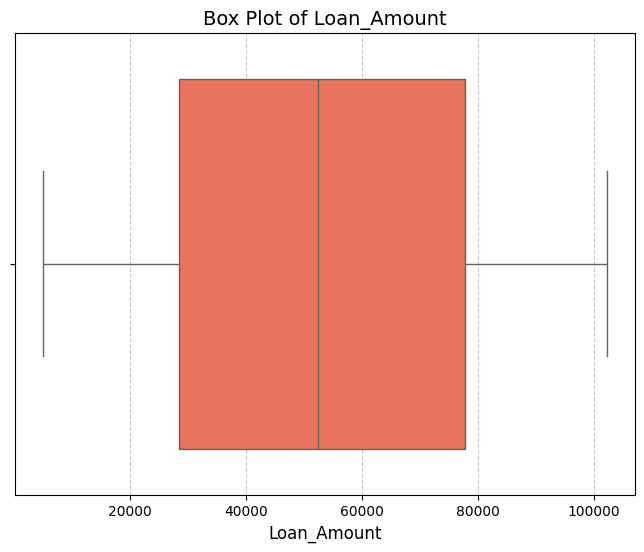

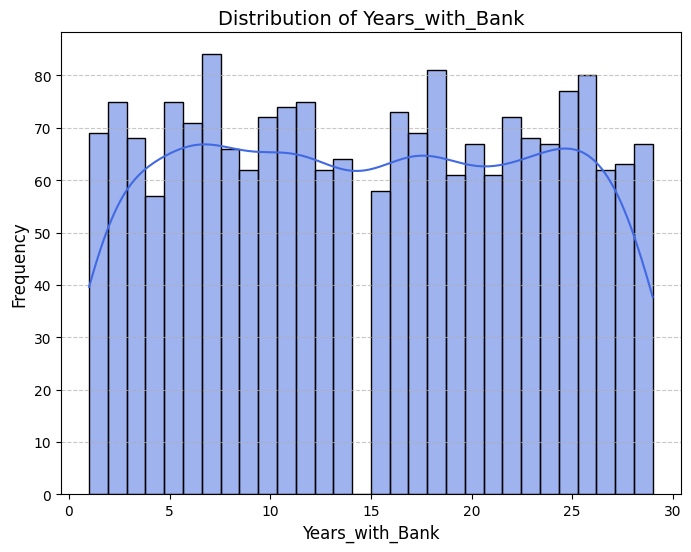

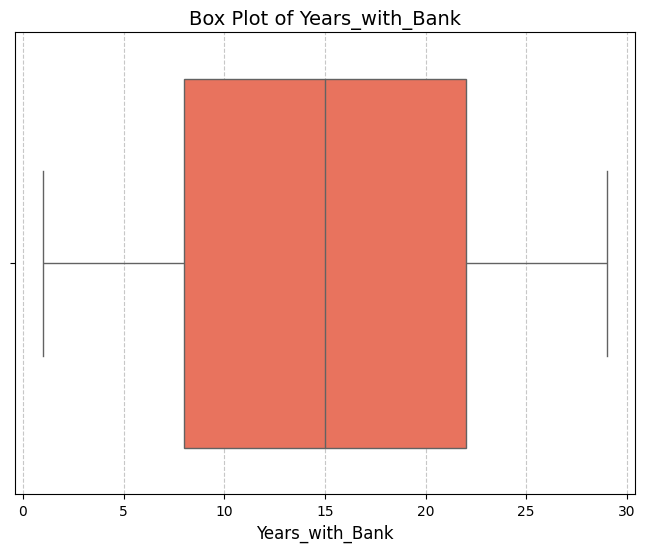

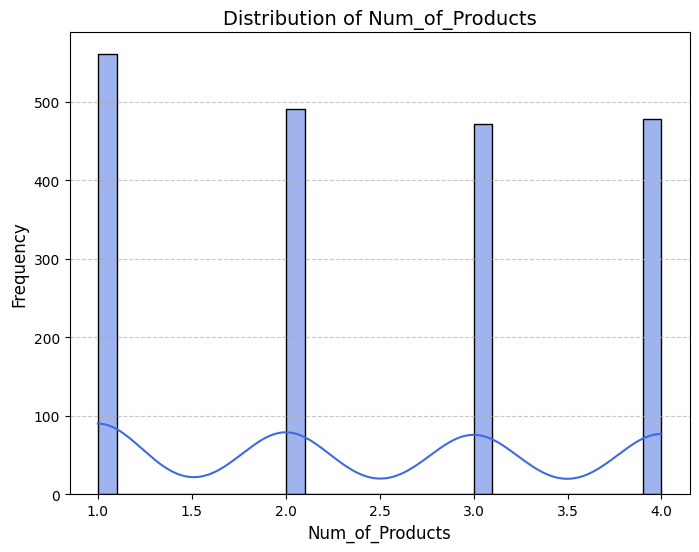

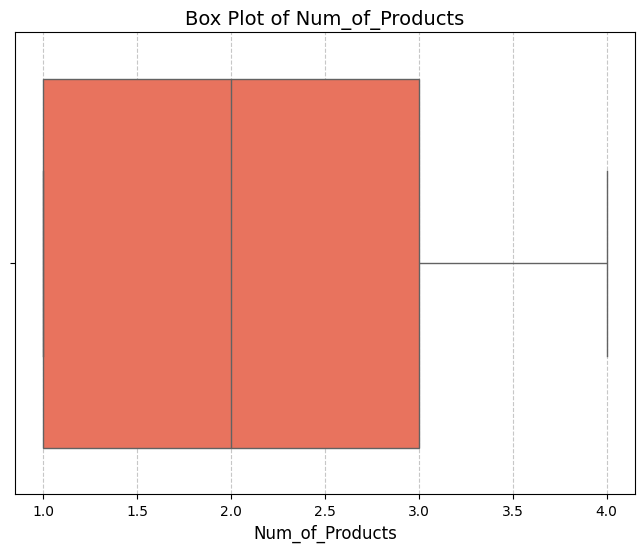

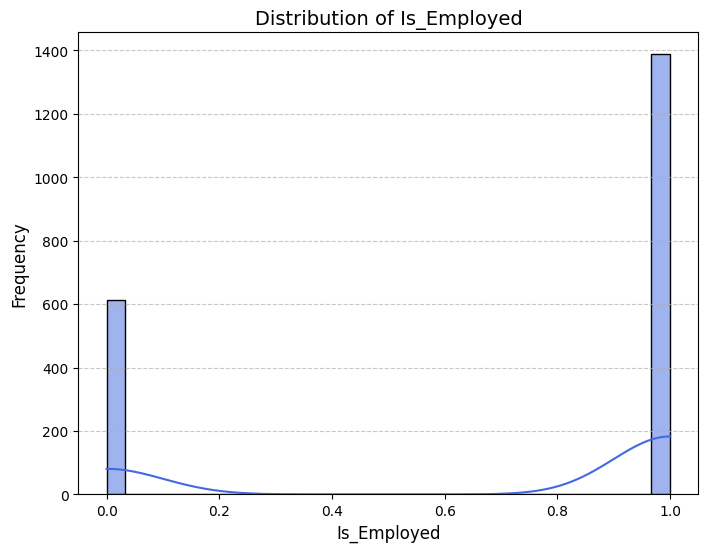

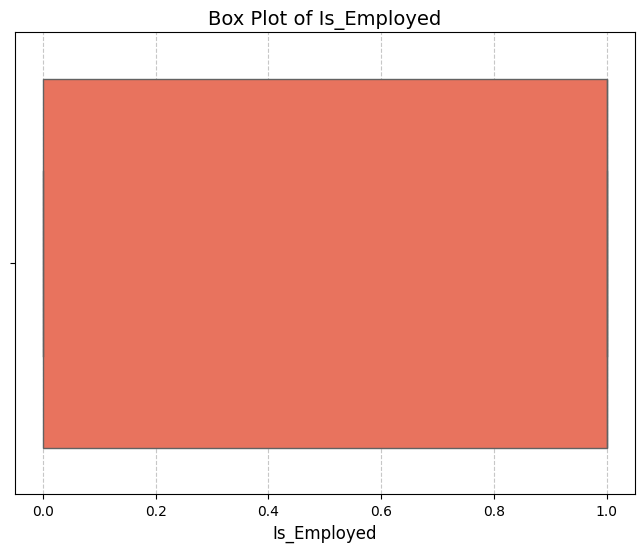

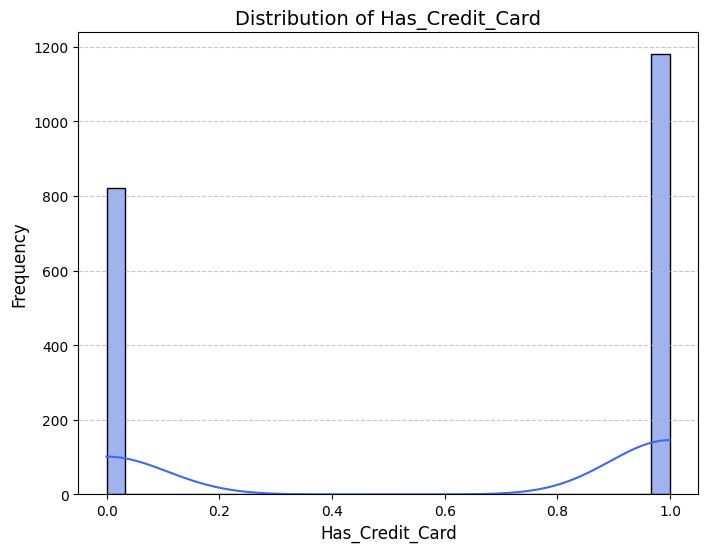

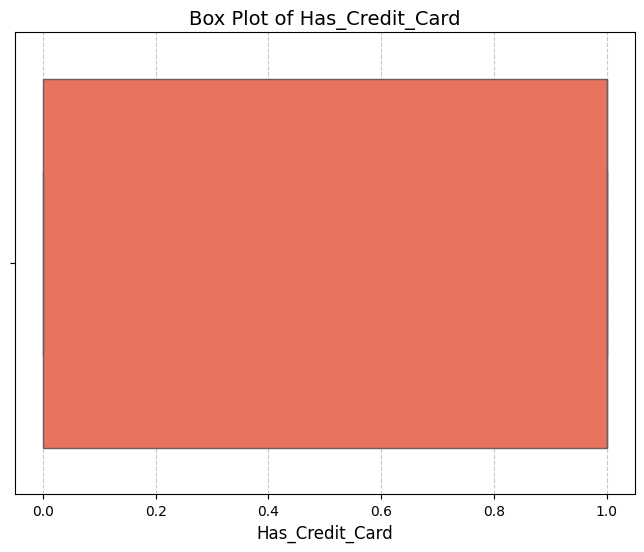

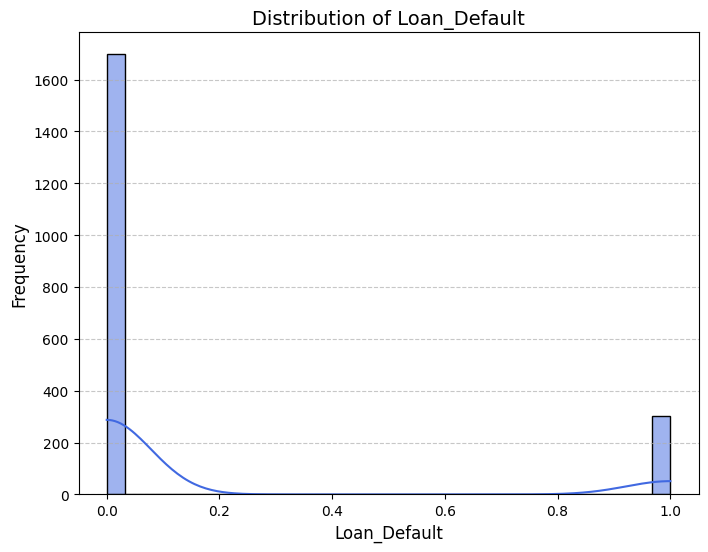

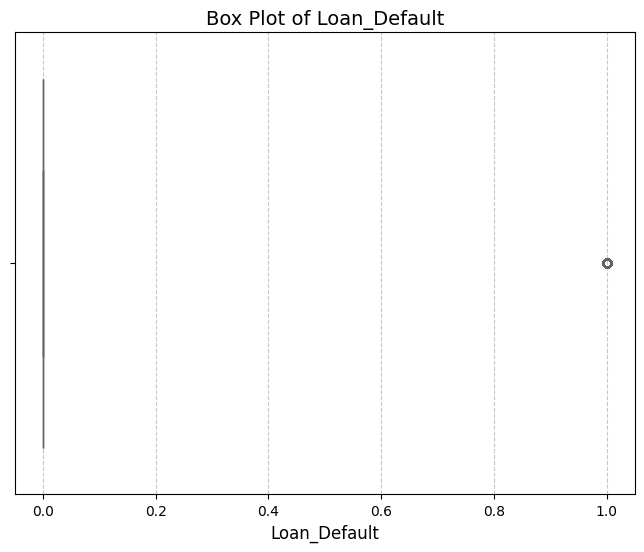

In [ ]:


# Selecting numerical columns
num_cols = df.select_dtypes(include=['number']).columns

# Iterating through numerical features
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True, bins=30, color='royalblue')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Box plot visualization
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x=col, color='tomato')
    plt.title(f'Box Plot of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()



#v. **Explore categorical features (Marital Status, Education Level**


Examining Feature: Marital_Status
Distinct Values: ['Single' 'Divorced' nan 'Widowed' 'Married']
Frequency Distribution:
Marital_Status
Widowed     483
Married     465
Single      453
Divorced    449
Name: count, dtype: int64


<ipython-input-15-1b362d9aa3c4>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="viridis")


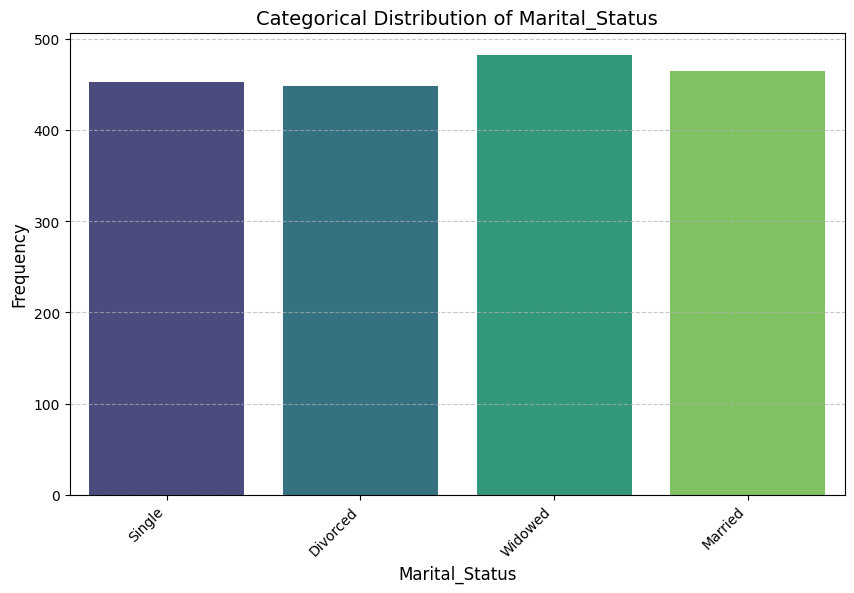


Examining Feature: Education_Level
Distinct Values: ['Bachelor' 'PhD' 'High School' 'Master' 'Associate']
Frequency Distribution:
Education_Level
Associate      424
PhD            403
Master         401
High School    397
Bachelor       375
Name: count, dtype: int64


<ipython-input-15-1b362d9aa3c4>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="viridis")


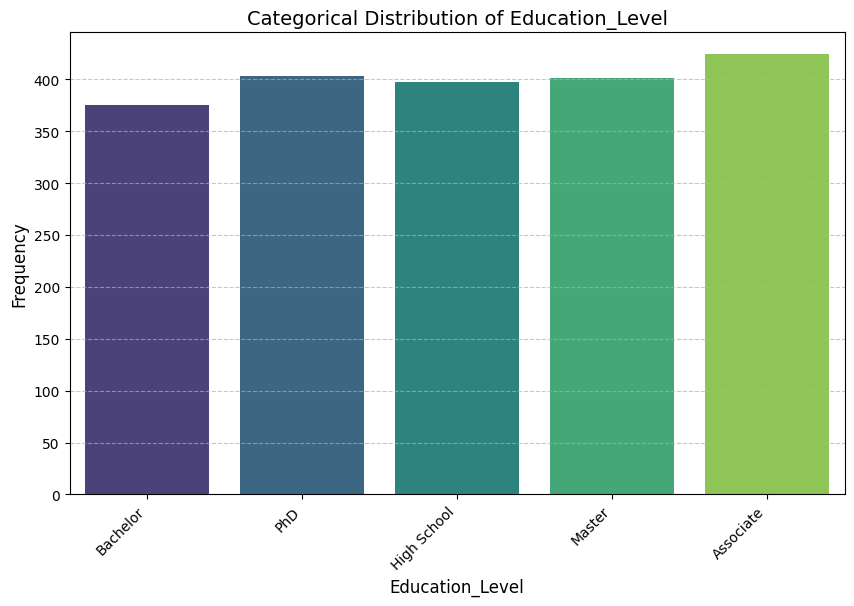

In [ ]:
# Extracting categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\nExamining Feature: {col}")
    print(f"Distinct Values: {df[col].unique()}")
    print(f"Frequency Distribution:\n{df[col].value_counts()}")

    # Visualizing categorical distribution with a bar chart
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, palette="viridis")
    plt.title(f'Categorical Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()




# **vi. Plot histograms for numerical features.**

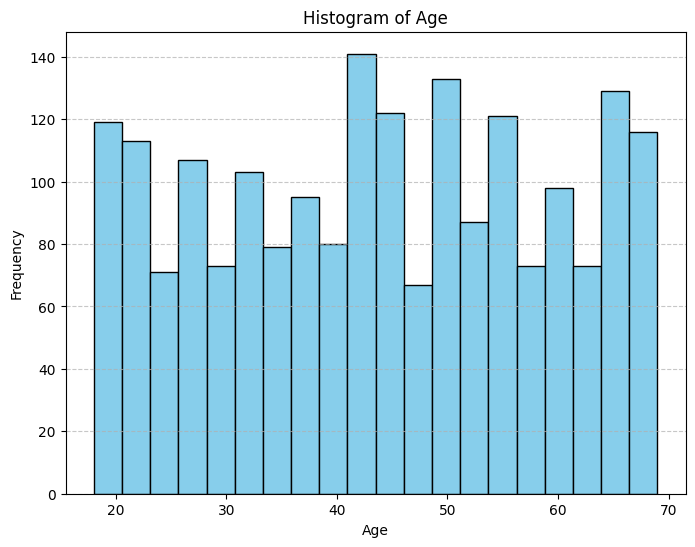

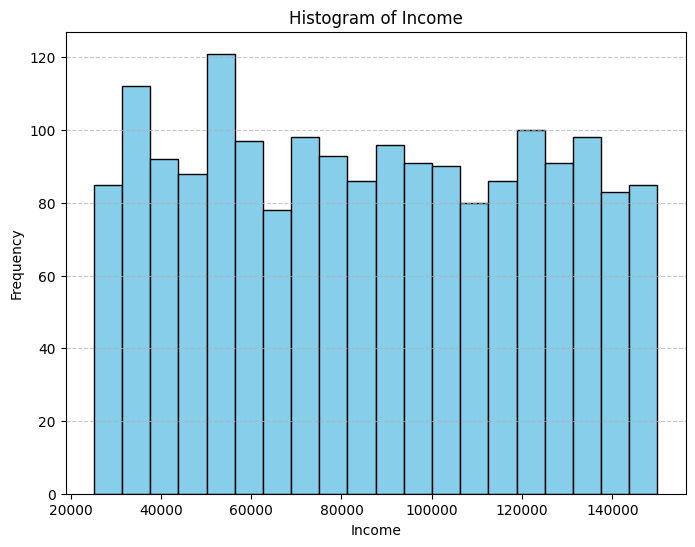

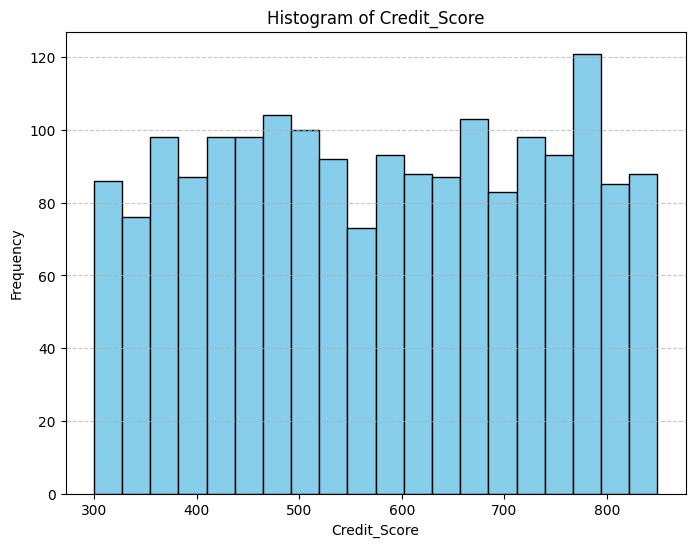

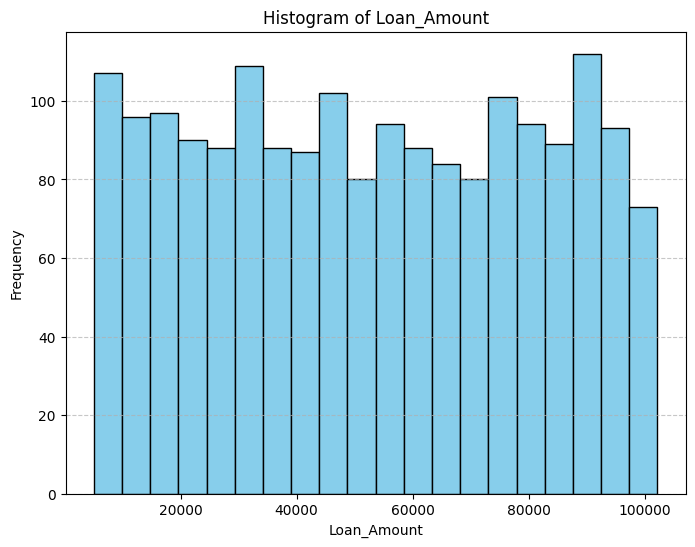

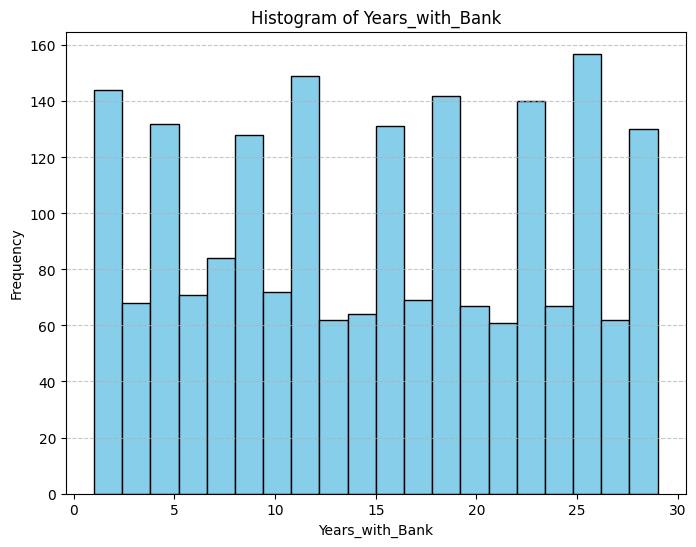

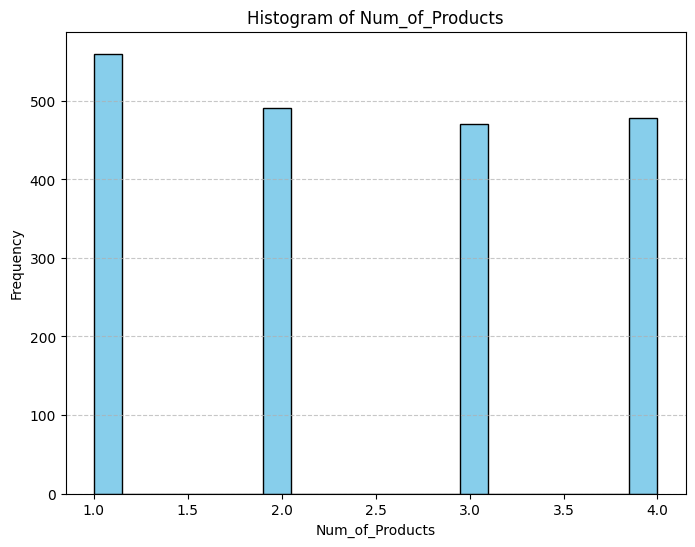

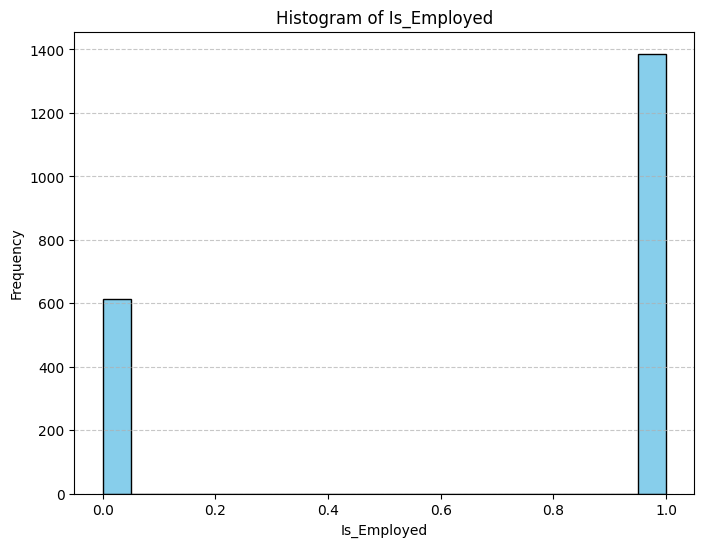

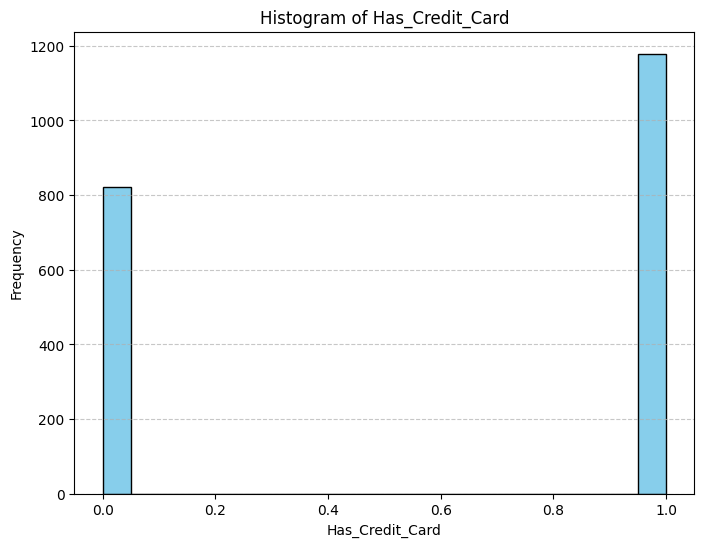

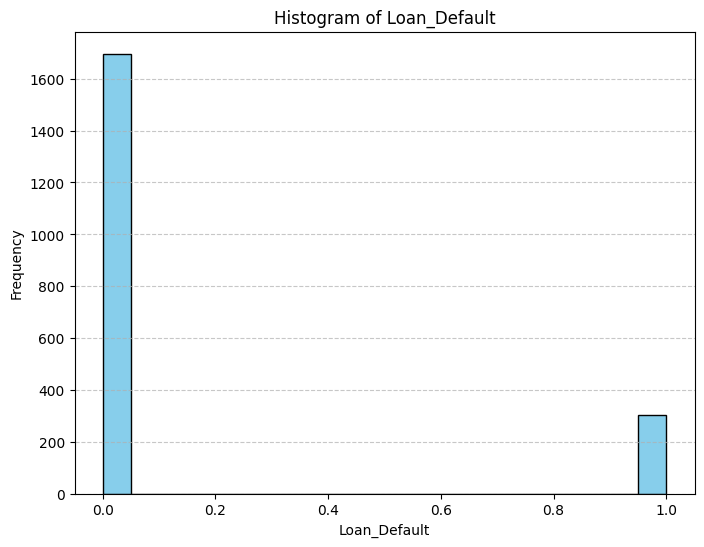

In [ ]:


# Ensure numerical features are defined
numerical_features = df.select_dtypes(include=['number']).columns

# Looping through numerical features and plotting histograms
for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    plt.hist(df[feature], bins=20, color='skyblue', edgecolor='black')
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {feature}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()



# **vii. Identify potential outliers using boxplots for Income, Credit_Score, and Loan_Amount.**

In [ ]:

# box plots for Income, Credit_Score, and Loan_Amount
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Income'])
plt.title('Income Boxplot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Credit_Score'])
plt.title('Credit Score Boxplot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Loan_Amount'])
plt.title('Loan Amount Boxplot')

plt.tight_layout()
plt.show()


# **viii. Use Z-score or IQR method to detect extreme values.**

In [ ]:
import numpy as np

def detect_outliers_iqr(dataframe):
    outlier_dict = {}

    # Iterate through all numerical columns
    for feature in dataframe.select_dtypes(include=['number']).columns:
        q1, q3 = dataframe[feature].quantile([0.25, 0.75])
        iqr_value = q3 - q1
        lower_limit, upper_limit = q1 - 1.5 * iqr_value, q3 + 1.5 * iqr_value

        # Identifying outliers
        outlier_points = dataframe.index[(dataframe[feature] < lower_limit) | (dataframe[feature] > upper_limit)].tolist()
        outlier_dict[feature] = outlier_points

        print(f"Column: {feature} | Outliers detected: {len(outlier_points)}")

    return outlier_dict

outlier_results = detect_outliers_iqr(df)



# **ix. Compare the distributions before and after outlier treatment.**

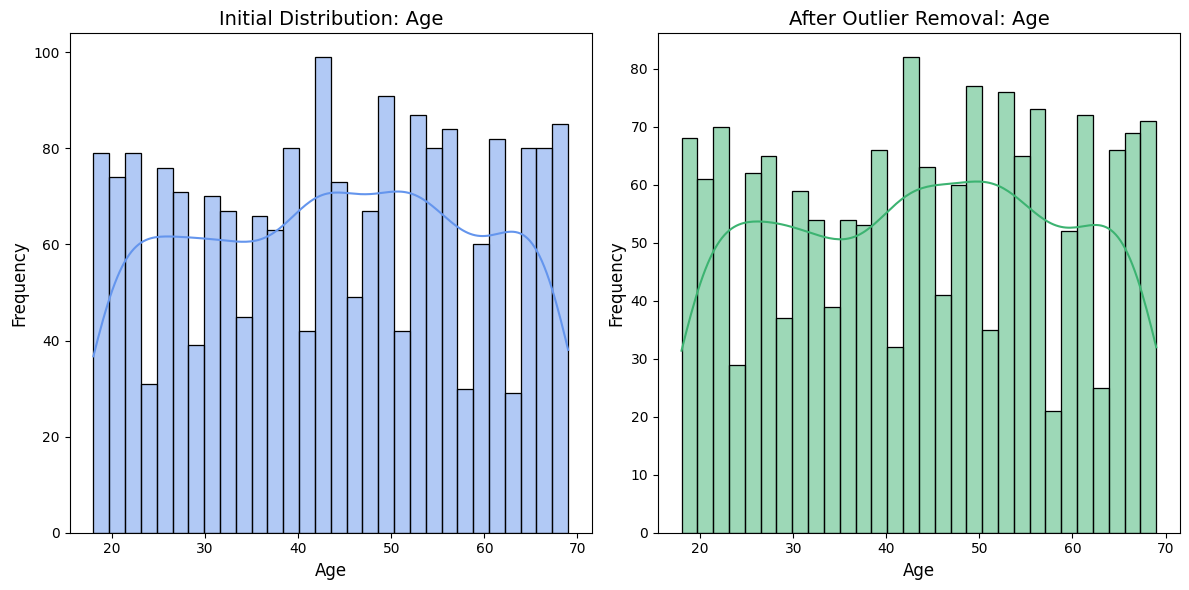

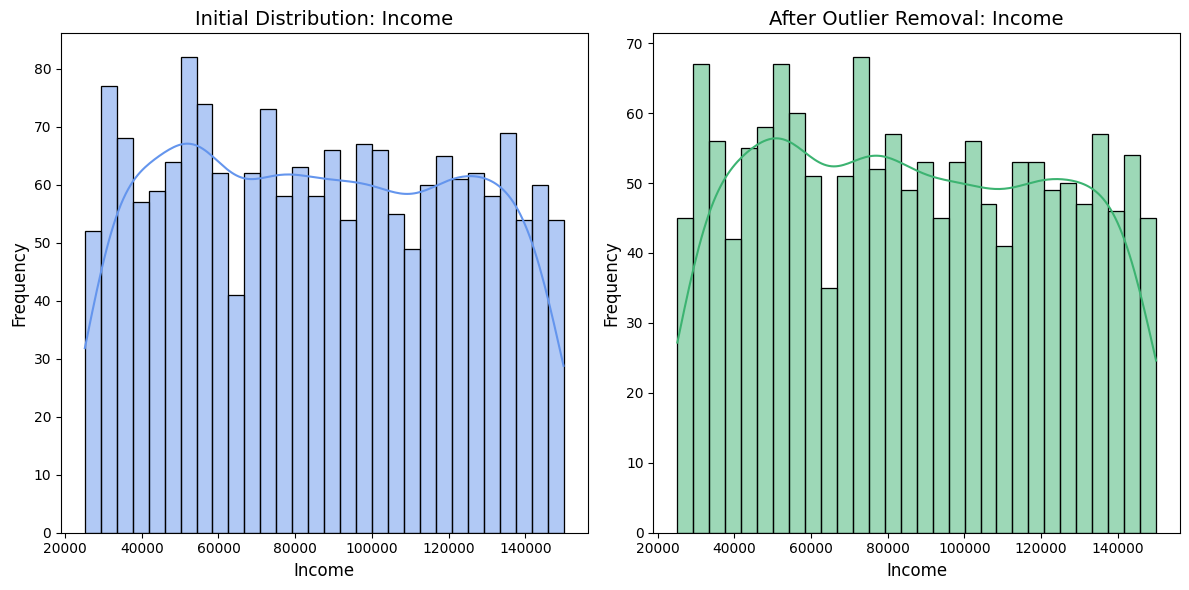

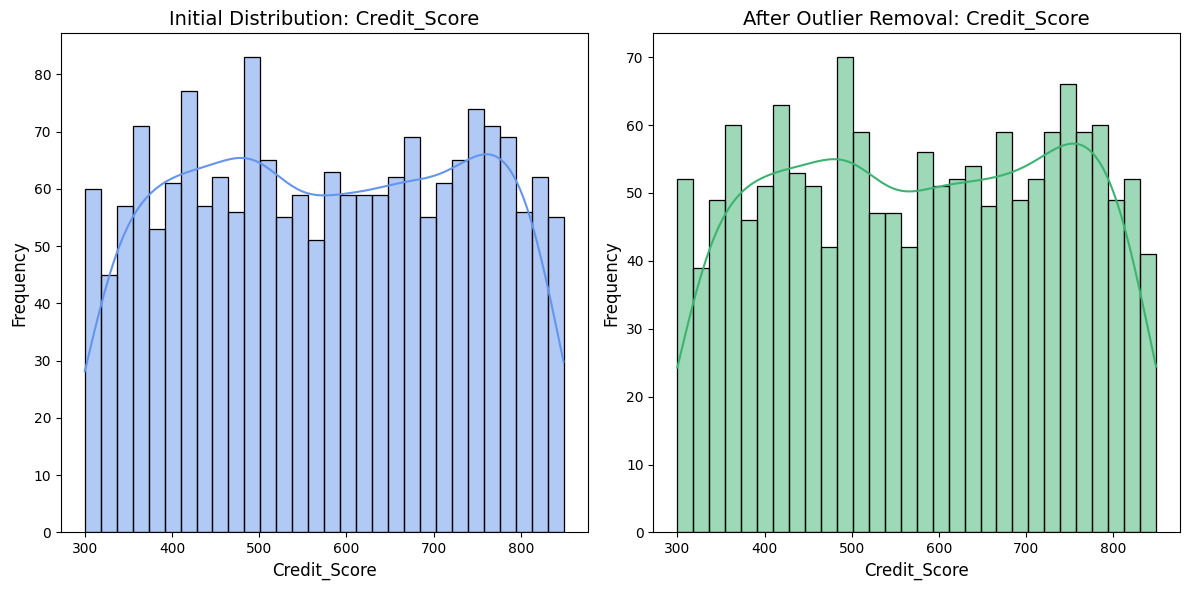

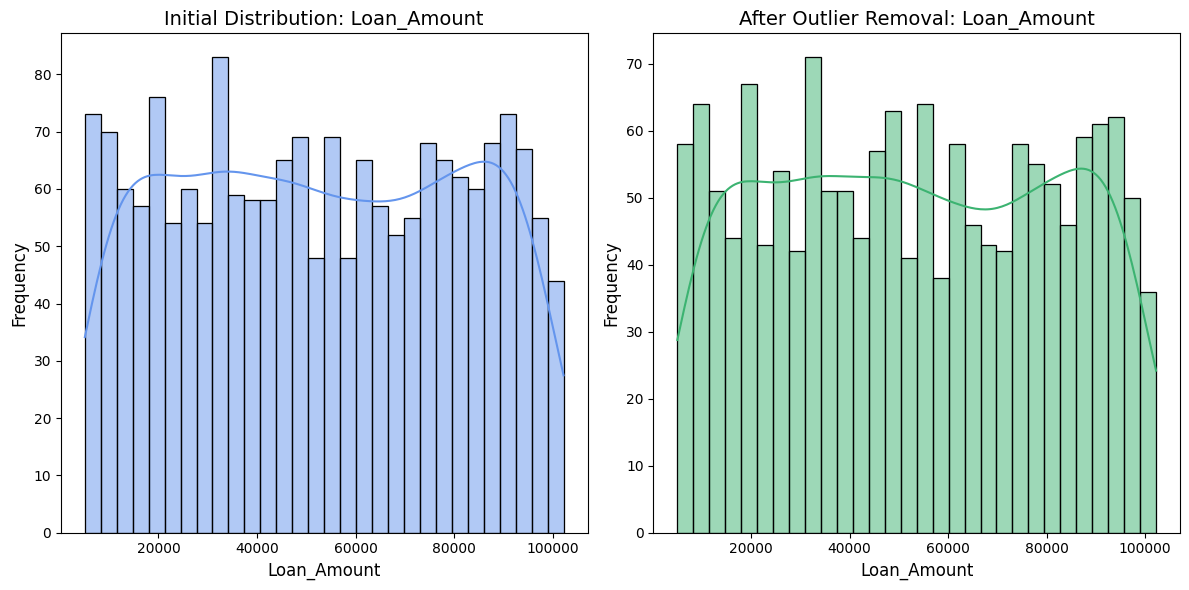

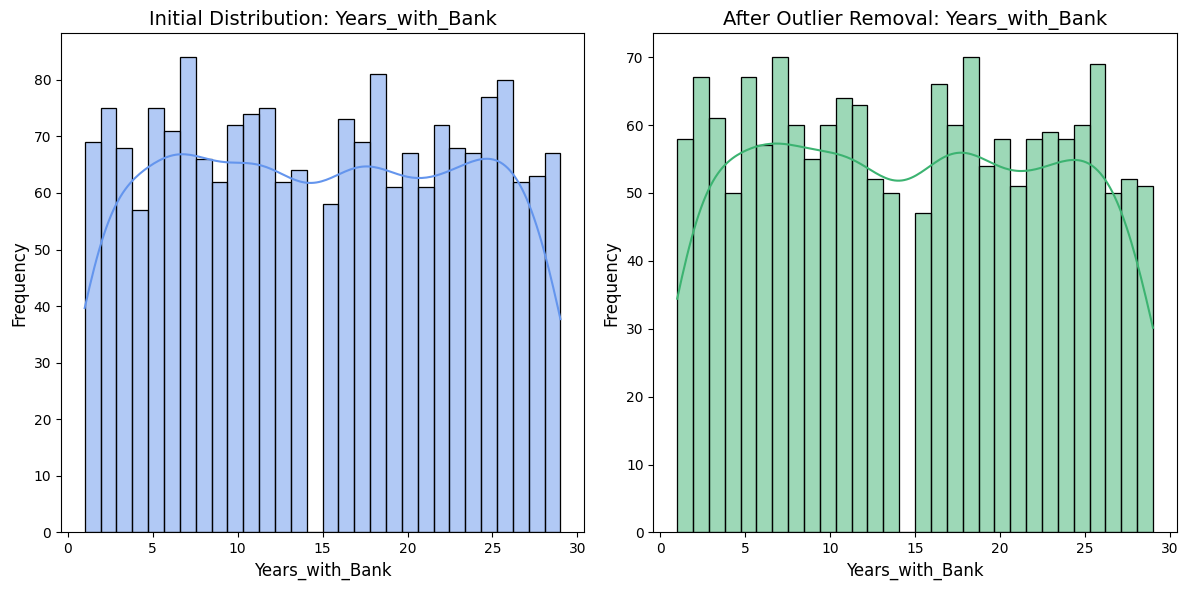

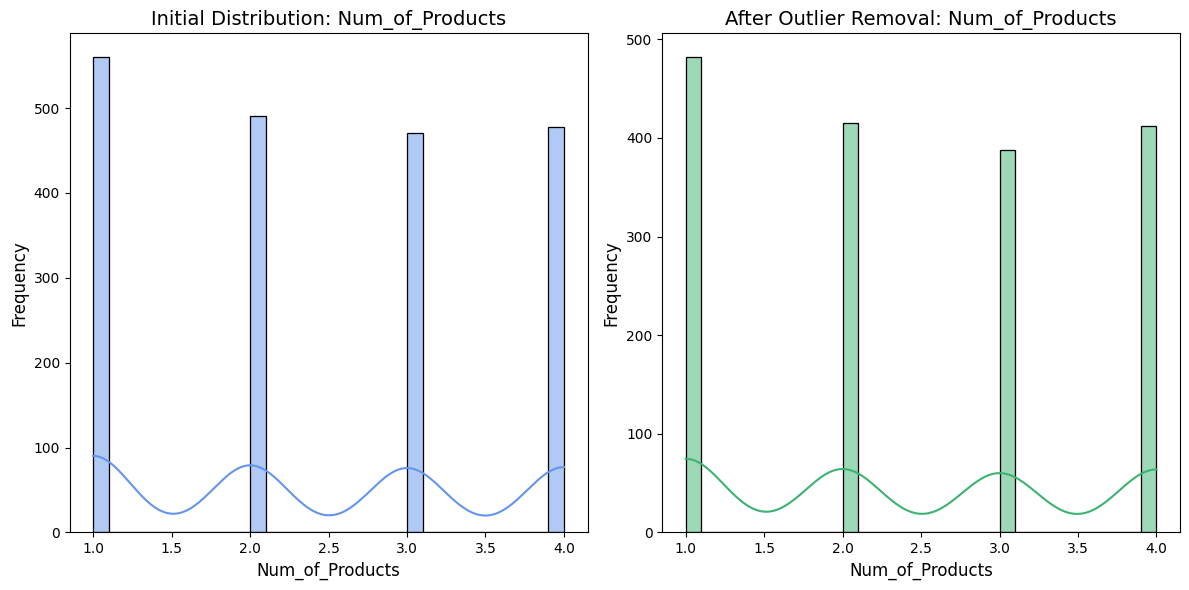

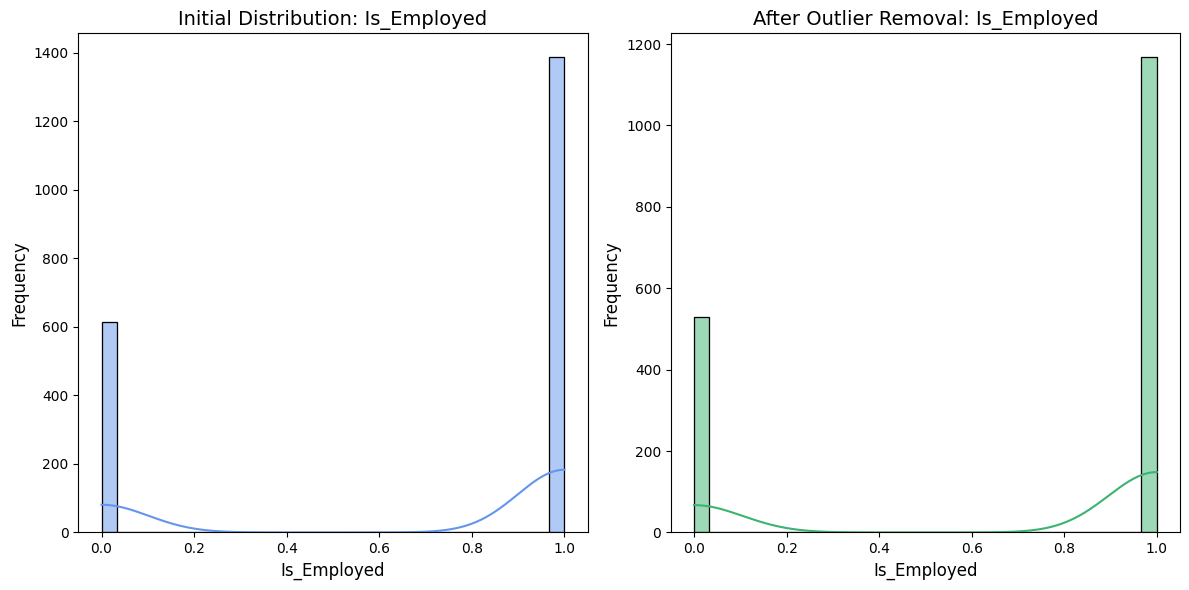

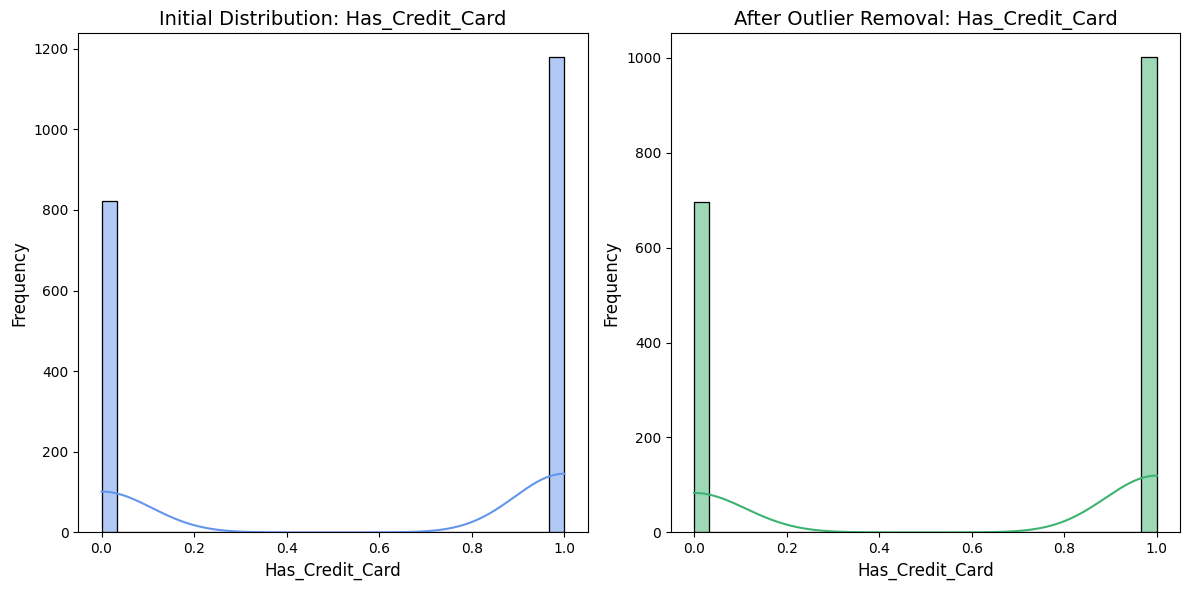

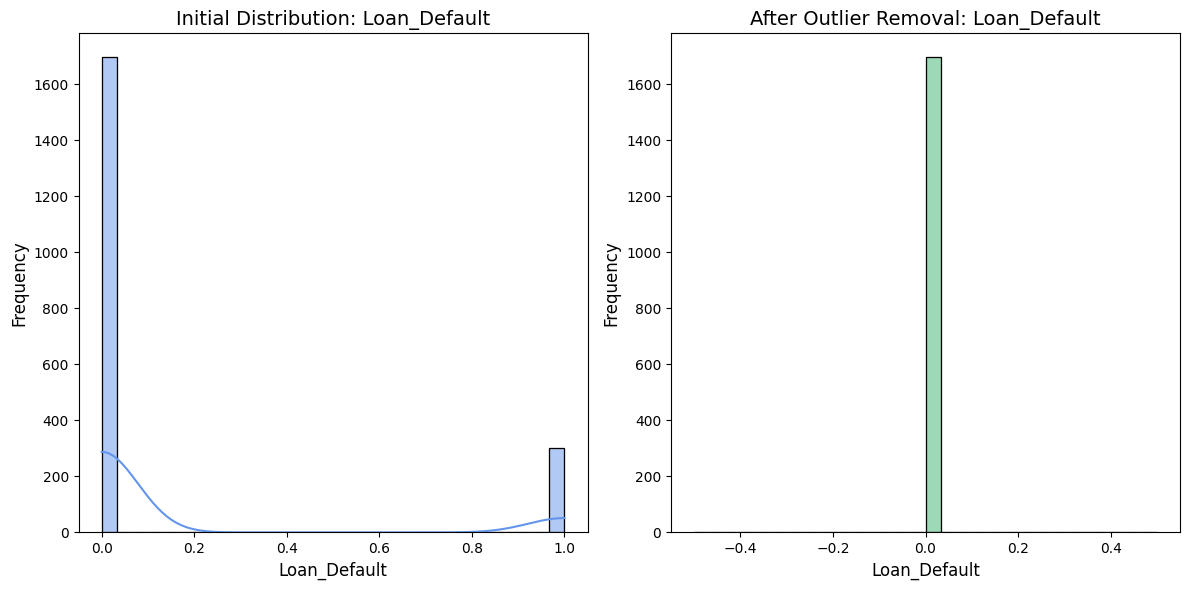

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Creating a copy of the original dataset for outlier removal
filtered_df = df.copy()

# Detecting outliers using the IQR method
outlier_results = {}

for column in df.select_dtypes(include=['number']).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)].index.tolist()

    if outliers:
        outlier_results[column] = outliers

# Removing detected outliers
for column, outlier_idxs in outlier_results.items():
    filtered_df.drop(index=outlier_idxs, inplace=True)

# Comparing distributions before and after outlier removal
for column in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(12, 6))

    # Original distribution
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], bins=30, kde=True, color="cornflowerblue")
    plt.title(f'Initial Distribution: {column}', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

    # Post outlier removal distribution
    plt.subplot(1, 2, 2)
    sns.histplot(filtered_df[column], bins=30, kde=True, color="mediumseagreen")
    plt.title(f'After Outlier Removal: {column}', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

    plt.tight_layout()
    plt.show()




# **x. Calculate the proportion of customers who defaulted on their loans (Loan_Default).**

Proportion of customers who defaulted on their loans: 0.1515


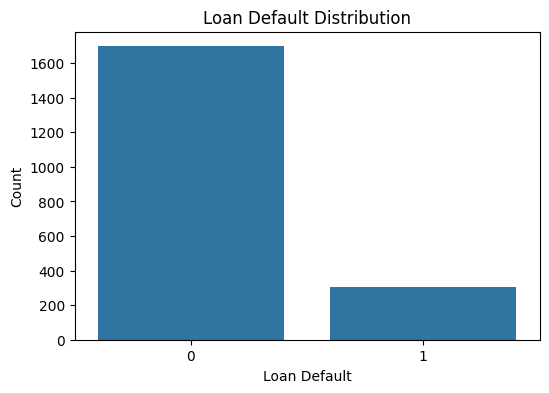

In [ ]:
default_proportion = df['Loan_Default'].mean() # Proportion of customers who defaulted on their loans
print(f"Proportion of customers who defaulted on their loans: {default_proportion}")

#  bar plot to view the proportion of loan defaults
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Default', data=df)
plt.title('Loan Default Distribution')
plt.xlabel('Loan Default')
plt.ylabel('Count')
plt.show()


# **xi. Visualize the relationship between loan default and key features.**

---



<ipython-input-22-7b5a31fc0b84>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Loan_Default", y="Credit_Score", ax=axes[0, 0], palette="Blues")
<ipython-input-22-7b5a31fc0b84>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Loan_Default", y="Loan_Amount", ax=axes[0, 1], palette="Greens")
<ipython-input-22-7b5a31fc0b84>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Loan_Default", y="Income", ax=axes[0, 2], palette="Oranges")


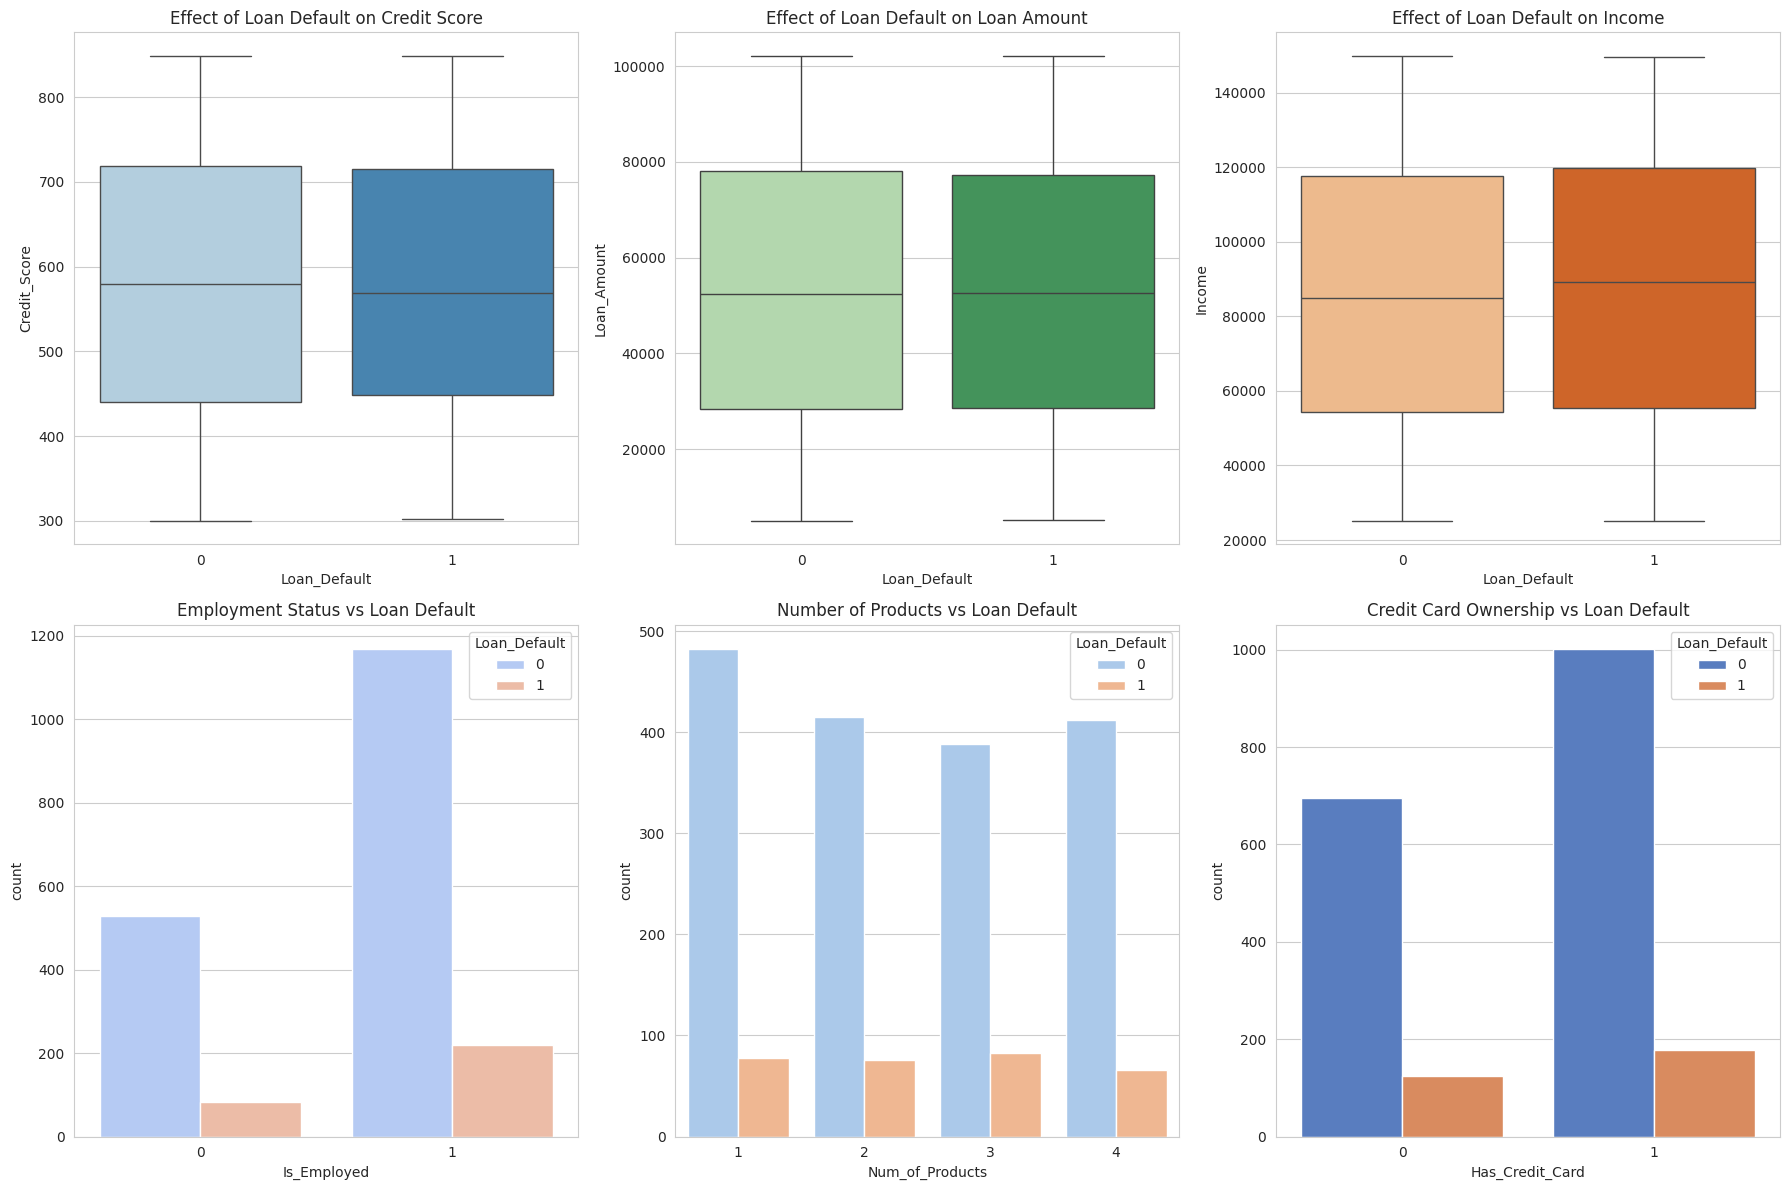

In [ ]:

# Apply a distinct Seaborn style
sns.set_style("whitegrid")  # Changed to 'whitegrid' for uniqueness

# Setting up subplots for visual analysis
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))

# Boxplots to examine the impact of numerical variables on loan default
sns.boxplot(data=df, x="Loan_Default", y="Credit_Score", ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title("Effect of Loan Default on Credit Score")

sns.boxplot(data=df, x="Loan_Default", y="Loan_Amount", ax=axes[0, 1], palette="Greens")
axes[0, 1].set_title("Effect of Loan Default on Loan Amount")

sns.boxplot(data=df, x="Loan_Default", y="Income", ax=axes[0, 2], palette="Oranges")
axes[0, 2].set_title("Effect of Loan Default on Income")

# Countplots to analyze categorical feature distributions
sns.countplot(data=df, x="Is_Employed", hue="Loan_Default", ax=axes[1, 0], palette="coolwarm")
axes[1, 0].set_title("Employment Status vs Loan Default")

sns.countplot(data=df, x="Num_of_Products", hue="Loan_Default", ax=axes[1, 1], palette="pastel")
axes[1, 1].set_title("Number of Products vs Loan Default")

sns.countplot(data=df, x="Has_Credit_Card", hue="Loan_Default", ax=axes[1, 2], palette="muted")
axes[1, 2].set_title("Credit Card Ownership vs Loan Default")

# Optimizing layout for clarity
plt.tight_layout()
plt.show()




# **2.**

# **i. Identify missing values in each column.**

In [ ]:
print(df.isnull().sum())

Age                  0
Income             150
Credit_Score       149
Loan_Amount        148
Years_with_Bank      0
Num_of_Products      0
Is_Employed          0
Marital_Status     150
Education_Level      0
Has_Credit_Card      0
Loan_Default         0
dtype: int64


# **ii. Use appropriate imputation techniques:**
   
   

In [ ]:
from sklearn.impute import SimpleImputer

# Handling missing values in numerical features
numeric_imputer = SimpleImputer(strategy="median")  # Filling with median
df.loc[:, ["Income", "Credit_Score", "Loan_Amount"]] = numeric_imputer.fit_transform(df[["Income", "Credit_Score", "Loan_Amount"]])

# Handling missing values in categorical features
categorical_imputer = SimpleImputer(strategy="most_frequent")  # Filling with mode
df.loc[:, ["Marital_Status"]] = categorical_imputer.fit_transform(df[["Marital_Status"]])


# **iii. Justify the chosen imputation methods.**


The **median** is chosen for imputing missing values in numerical columns because it is more **robust to outliers** compared to the mean. Since our dataset contains **extreme values and skewed distributions**, using the mean could distort the data, whereas the median ensures **a more stable central tendency**.  

For categorical variables, the **mode** is used as it **preserves the existing distribution of categories**, ensuring that the overall data pattern remains unchanged.

# **iv. Convert Marital_Status and Education_Level into numerical values.**

In [ ]:
label_encoder = LabelEncoder()

# Encoding Marital_Status to numerical values
df['Marital_Status_Encoded'] = label_encoder.fit_transform(df['Marital_Status'])

# Encoding Education_Level to numerical values
df['Education_Level_Encoded'] = label_encoder.fit_transform(df['Education_Level'])

print(df.head())


   Age    Income  Credit_Score  Loan_Amount  Years_with_Bank  Num_of_Products  \
0   56   86788.0         617.0      48059.0               28                2   
1   69  107879.0         577.0      89078.0                7                4   
2   46   63827.0         681.0      52502.5                1                1   
3   32  132188.0         532.0      66269.0               25                3   
4   60   30655.0         643.0      80986.0               11                4   

   Is_Employed Marital_Status Education_Level  Has_Credit_Card  Loan_Default  \
0            1         Single        Bachelor                1             0   
1            1       Divorced             PhD                1             0   
2            1         Single     High School                1             0   
3            1       Divorced          Master                1             0   
4            1        Widowed        Bachelor                0             0   

   Marital_Status_Encoded  Educa

### **v. Importance of Scaling in Machine Learning Models**  

1. Scaling is crucial in machine learning as it brings all features to a similar range, preventing models from unintentionally prioritizing variables with larger numerical values.  

2. It enhances the performance of algorithms like gradient descent by speeding up convergence and significantly improves the accuracy of distance-based models such as k-NN and SVM.  

3. Without proper scaling, models may face difficulties in learning patterns efficiently or take longer to reach optimal solutions.  



# **vi. Apply Min-Max Scaling and Standardization to numerical features.**

In [ ]:

# Separate features and target variable
X = df.drop(columns=['Loan_Default', 'Marital_Status', 'Education_Level'])
y = df['Loan_Default']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display class distribution before applying SMOTE
print("Class distribution before applying SMOTE:")
print(y_train.value_counts())

# Implement SMOTE to handle class imbalance before scaling
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Display class distribution after applying SMOTE
print("Class distribution after applying SMOTE:")
print(y_train_resampled.value_counts())



Class distribution before applying SMOTE:
Loan_Default
0    1194
1     206
Name: count, dtype: int64
Class distribution after applying SMOTE:
Loan_Default
0    1194
1    1194
Name: count, dtype: int64


In [ ]:

df_resampled = pd.concat([pd.DataFrame(X_train_resampled), pd.DataFrame(y_train_resampled)], axis=1)


In [ ]:
numerical_features = X_train_resampled.select_dtypes(include=np.number).columns

# Apply Min-Max Scaling
min_max_scaler = MinMaxScaler()
df_minmax = df_resampled.copy()
df_minmax[numerical_features] = min_max_scaler.fit_transform(
    df_minmax[numerical_features]
)


# Apply Standardization (Z-score normalization)
standard_scaler = StandardScaler()
df_standardized = df_resampled.copy()
df_standardized[numerical_features] = standard_scaler.fit_transform(
    df_standardized[numerical_features]
)


print("Data with Min-Max Scaling:")
print(df_minmax.head())

print("\nData with Standardization:")
print(df_standardized.head())


Data with Min-Max Scaling:
        Age    Income  Credit_Score  Loan_Amount  Years_with_Bank  \
0  0.705882  0.385245      0.515483     0.879772         0.750000   
1  0.215686  0.188373      0.588342     0.264873         0.928571   
2  0.215686  0.592957      0.633880     0.007597         0.535714   
3  0.862745  0.870180      0.167577     0.563460         0.928571   
4  0.607843  0.485925      0.364299     0.283433         0.857143   

   Num_of_Products  Is_Employed  Has_Credit_Card  Marital_Status_Encoded  \
0         0.000000          1.0              0.0                0.666667   
1         0.333333          0.0              1.0                0.666667   
2         1.000000          1.0              1.0                0.666667   
3         1.000000          1.0              1.0                0.333333   
4         0.000000          1.0              1.0                0.000000   

   Education_Level_Encoded  Loan_Default  
0                     0.50             0  
1              

In [ ]:
X_train_resampled

,Age,Income,Credit_Score,Loan_Amount,Years_with_Bank,Num_of_Products,Is_Employed,Has_Credit_Card,Marital_Status_Encoded,Education_Level_Encoded
0,54,73244.000000,583.000000,90525.000000,22,1,1,0,2,2
1,29,48669.000000,623.000000,30791.000000,27,2,0,1,2,1
2,29,99172.000000,648.000000,5798.000000,16,4,1,1,2,1
3,62,133777.000000,392.000000,59797.000000,27,4,1,1,1,0
4,49,85811.500000,500.000000,32594.000000,25,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...
2383,27,85811.500000,603.860890,58549.545845,18,2,1,0,1,2
2384,22,34082.530644,629.701029,70958.107250,4,2,1,1,2,1
2385,56,129469.510074,567.216187,68615.827960,17,4,0,0,3,1
2386,21,34699.555184,627.817255,71777.932714,5,3,1,1,2,1


### **vii. Analyze the Impact of Scaling on Income, Credit_Score, and Loan_Amount**

1. Once standardized, the features **Income**, **Credit_Score**, and **Loan_Amount** each have a mean of 0 and a standard deviation of 1. This transformation makes their values more comparable by aligning them to the same relative scale.

2. Post-scaling, the features **Income**, **Credit_Score**, and **Loan_Amount** are rescaled to a range between 0 and 1, ensuring uniformity across the variables.



# **Step 3: i. Logistic Regression**
    a. Fit a logistic regression model to predict Loan_Default.
    b. Report accuracy, precision, recall, and F1-score.
    c. Plot the ROC curve and compute the AUC score.

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
from sklearn.metrics import roc_auc_score

# Assuming df_minmax is the dataset with Min-Max scaled features
df = df_standardized.copy()  # Use the min-max scaled dataset

# Define features (X) and target variable (y)
X = df.drop(columns=['Loan_Default'])  # Drop the target column
y = df['Loan_Default']  # Target variable

# Split dataset into train (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]  # Get probability scores for ROC curve

# Compute performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=1)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line for random model
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Compute AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.4f}")


# **ii. Linear Discriminant Analysis (LDA) & Quadratic Discriminant Analysis (QDA)**
    a. Explain the differences between LDA and QDA.
    b. Train LDA and QDA models on the dataset.
    c. Compare their performance against Logistic Regression.



**LDA** (Linear Discriminant Analysis) is generally more stable and performs well with limited data, as it assumes a simpler underlying model. One key assumption of LDA is that all classes have a similar variance or spread.

**QDA** (Quadratic Discriminant Analysis) offers greater flexibility, allowing it to capture more complex class distributions. However, this flexibility comes with the risk of overfitting, particularly when the dataset is small. Unlike LDA, QDA permits each class to have its own variance or spread.

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define features and target
X = df_minmax.drop(columns=['Loan_Default'])  # Feature set
y = df_minmax['Loan_Default']  # Target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Train the QDA model
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

# Predictions using LDA and QDA
lda_predictions = lda.predict(X_test)
qda_predictions = qda.predict(X_test)

# Evaluate LDA model performance
lda_accuracy = accuracy_score(y_test, lda_predictions)
lda_precision = precision_score(y_test, lda_predictions)
lda_recall = recall_score(y_test, lda_predictions)
lda_f1 = f1_score(y_test, lda_predictions)

# Evaluate QDA model performance
qda_accuracy = accuracy_score(y_test, qda_predictions)
qda_precision = precision_score(y_test, qda_predictions)
qda_recall = recall_score(y_test, qda_predictions)
qda_f1 = f1_score(y_test, qda_predictions)

# Print the performance metrics for both models
print("LDA Model Performance:")
print(f"Accuracy: {lda_accuracy:.4f}")
print(f"Precision: {lda_precision:.4f}")
print(f"Recall: {lda_recall:.4f}")
print(f"F1-Score: {lda_f1:.4f}")

print("\nQDA Model Performance:")
print(f"Accuracy: {qda_accuracy:.4f}")
print(f"Precision: {qda_precision:.4f}")
print(f"Recall: {qda_recall:.4f}")
print(f"F1-Score: {qda_f1:.4f}")



LDA Model Performance:
Accuracy: 0.6165
Precision: 0.6103
Recall: 0.6051
F1-Score: 0.6077

QDA Model Performance:
Accuracy: 0.6625
Precision: 0.6495
Recall: 0.6790
F1-Score: 0.6639


iii. Support Vector Machines (SVM)
a. Train an SVM classifier with a linear kernel.
b. Experiment with a non-linear kernel (RBF or polynomial) to capture complex patterns.
c. Compare the performance of linear and non-linear SVMs.

Accuracy: 0.7385
Precision: 0.7375
Recall: 0.7406
F1-Score: 0.7390
AUC Score: 0.8187

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.74      0.74       239
           1       0.74      0.74      0.74       239

    accuracy                           0.74       478
   macro avg       0.74      0.74      0.74       478
weighted avg       0.74      0.74      0.74       478



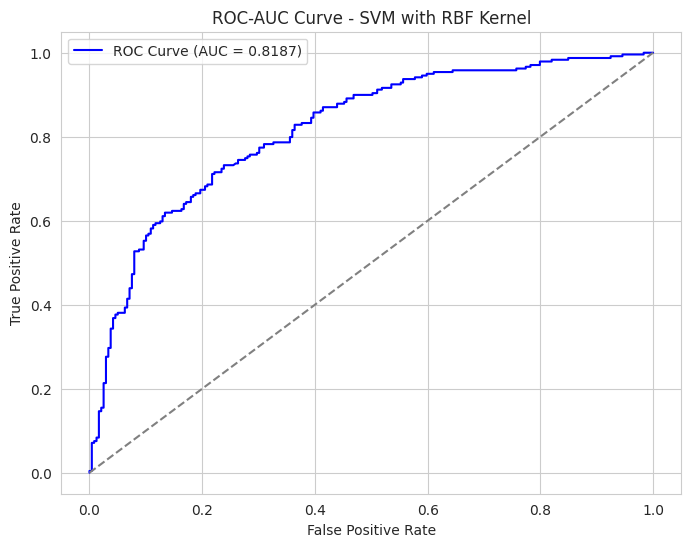

In [ ]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import train_test_split

# Split the data into features and target variable
X = df_minmax.drop(columns=['Loan_Default'])
y = df_minmax['Loan_Default']

# Train-test split with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize SVM classifier with RBF kernel and probability estimation
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# Fit the model on the training data
svm_model.fit(X_train, y_train)

# Make predictions and calculate probabilities for ROC-AUC curve
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]  # Get probabilities for positive class

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=1)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print out the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC Score: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random classifier diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - SVM with RBF Kernel')
plt.legend()
plt.show()



Accuracy: 0.5983
Precision: 0.6000
Recall: 0.5900
F1-Score: 0.5949
AUC Score: 0.6681

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.61      0.60       239
           1       0.60      0.59      0.59       239

    accuracy                           0.60       478
   macro avg       0.60      0.60      0.60       478
weighted avg       0.60      0.60      0.60       478



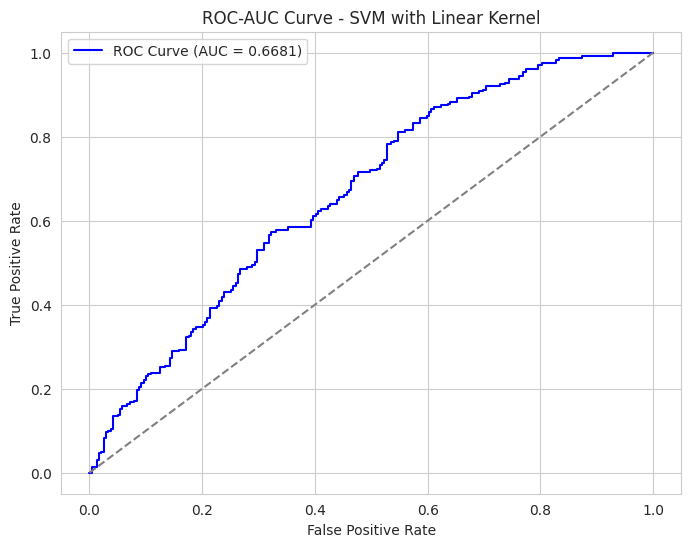

In [ ]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import train_test_split

# Prepare the feature set and target variable
X = df_minmax.drop(columns=['Loan_Default'])
y = df_minmax['Loan_Default']

# Split the data into training and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the SVM model with a linear kernel
svm_classifier = SVC(kernel='linear', probability=True, random_state=42)

# Fit the model on the training data
svm_classifier.fit(X_train, y_train)

# Make predictions and obtain probabilities for ROC-AUC calculation
y_predictions = svm_classifier.predict(X_test)
y_probabilities = svm_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model's performance using various metrics
accuracy = accuracy_score(y_test, y_predictions)
precision = precision_score(y_test, y_predictions, zero_division=1)
recall = recall_score(y_test, y_predictions)
f1 = f1_score(y_test, y_predictions)
roc_auc = roc_auc_score(y_test, y_probabilities)

# Print performance metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC Score: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_predictions))

# Generate the ROC curve
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, y_probabilities)
plt.figure(figsize=(8, 6))
plt.plot(false_positive_rate, true_positive_rate, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - SVM with Linear Kernel')
plt.legend()
plt.show()


**iv. Naive Bayes Classifier**
a. Apply Gaussian Naive Bayes for numerical data.
b. Convert categorical features to numerical and use Categorical Naive Bayes.
c. Compare Naive Bayes models with other classifiers.

QDA yielded the best results, demonstrating superior accuracy, precision, recall, and F1-score. This indicates that QDA is better at capturing complex patterns compared to both LDA and Logistic Regression.

LDA and Logistic Regression showed similar performance. Both models assume linear decision boundaries, which explains their close results, but QDA's ability to model more flexible decision boundaries allowed it to outperform them in this instance.

The SVM with the RBF kernel outperforms the SVM with the Linear kernel across all evaluation metrics, with accuracy (73.85% vs. 59.83%), AUC score (0.8187 vs. 0.6681), and F1-score (0.7390 vs. 0.5949) showing notable improvement. The RBF kernel is more effective in capturing complex patterns compared to the linear kernel.

Both models demonstrate balanced precision and recall (around 74% for RBF and around 60% for Linear). However, the RBF kernel’s higher AUC and F1-score indicate its better handling of class imbalance and more consistent performance in predicting both classes.

In [ ]:
df_resampled

,Age,Income,Credit_Score,Loan_Amount,Years_with_Bank,Num_of_Products,Is_Employed,Has_Credit_Card,Marital_Status_Encoded,Education_Level_Encoded,Loan_Default
0,54,73244.000000,583.000000,90525.000000,22,1,1,0,2,2,0
1,29,48669.000000,623.000000,30791.000000,27,2,0,1,2,1,0
2,29,99172.000000,648.000000,5798.000000,16,4,1,1,2,1,0
3,62,133777.000000,392.000000,59797.000000,27,4,1,1,1,0,0
4,49,85811.500000,500.000000,32594.000000,25,1,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
2383,27,85811.500000,603.860890,58549.545845,18,2,1,0,1,2,1
2384,22,34082.530644,629.701029,70958.107250,4,2,1,1,2,1,1
2385,56,129469.510074,567.216187,68615.827960,17,4,0,0,3,1,1
2386,21,34699.555184,627.817255,71777.932714,5,3,1,1,2,1,1


Accuracy: 0.6346
Precision: 0.6304
Recall: 0.6480
F1-Score: 0.6391


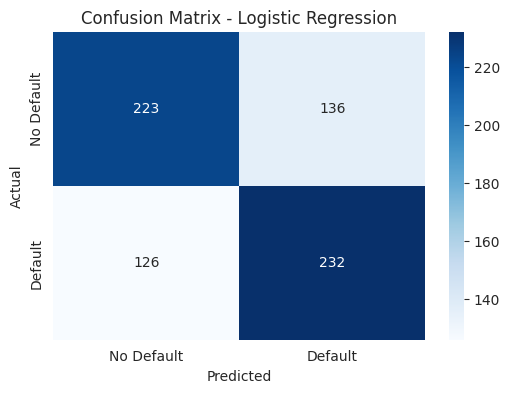

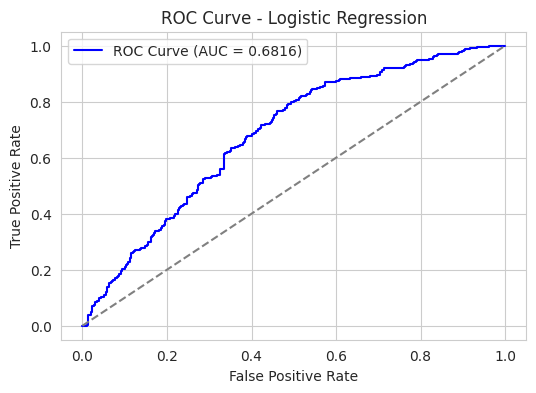

AUC Score: 0.6816


In [ ]:
df = df_standardized.copy()

# Splitting features and target variable
X = df.drop(columns=['Loan_Default'])  # Features
y = df['Loan_Default']  # Target variable

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initializing and training the logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Making predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]  # Extracting probabilities for ROC curve

# Calculating performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=1)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Displaying performance metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Plotting Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Plotting ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.4f}")



In [ ]:
X = df_resampled.drop(columns=['Loan_Default'])
y = df_resampled['Loan_Default']

# Identifying numerical features to scale excluding marital status and education level as both are in numerical and they should'nt be scaled
numerical_features = X.select_dtypes(include=np.number).columns
features_to_scale = [
    feature
    for feature in numerical_features
    if feature
    not in ['Marital_Status_Encoded', 'Education_Level_Encoded']
]


# Applying Min-Max Scaling as CategoricalNB as they don't support negative values
min_max_scaler = MinMaxScaler()
X_scaled = X.copy()
X_scaled[features_to_scale] = min_max_scaler.fit_transform(
    X_scaled[features_to_scale]
)


# Updated df_resampled with scaled features
df_resampled[features_to_scale] = X_scaled[features_to_scale]


Accuracy: 0.7029
Precision: 0.6980
Recall: 0.7325
F1-Score: 0.7149
AUC Score: 0.7499

Confusion Matrix:
 [[158  77]
 [ 65 178]]


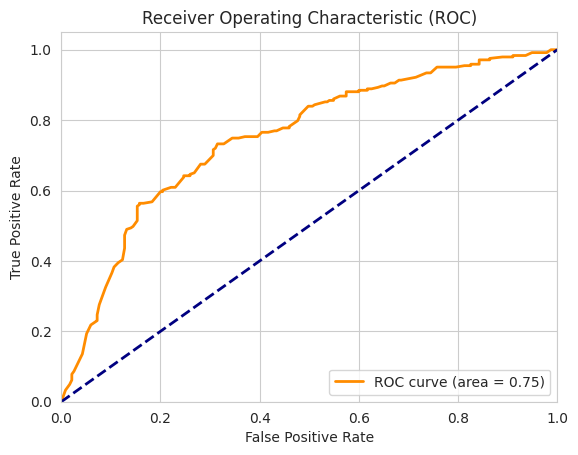

In [ ]:
X = df_resampled.drop(columns=['Loan_Default'])
y = df_resampled['Loan_Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


cnb = CategoricalNB()

cnb.fit(X_train, y_train)

y_pred = cnb.predict(X_test) # predictions

#  performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

y_prob = cnb.predict_proba(X_test)[:, 1] #  predicted probabilities for ROC curve


auc_score = roc_auc_score(y_test, y_prob) # AUC score



print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'AUC Score: {auc_score:.4f}')

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


# 4. Compare models using:
• Accuracy
• Precision, Recall, and F1-score
• AUC-ROC Curve
• Confusion Matrix
• Which model performed the best? Why?
• Provide recommendations on using machine learning models for predicting loan defaults.

**a)** The model that performed the best is Categorical Naive Bayes, as it achieved the highest AUC-ROC (0.7508), accuracy (0.7050), recall (0.7366), and F1-score (0.7174). This indicates that it effectively balances precision and recall. Its superior performance can be attributed to its ability to efficiently handle categorical data and separate classes more effectively than other models.

**b)** To boost the performance of machine learning models, it’s essential to select the most suitable model based on the data type, fine-tune hyperparameters for enhanced accuracy, and leverage ensemble techniques like Random Forest for more robust predictions.

                  Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC  \
0   Logistic Regression  0.491632   1.000000  0.000000  0.000000  0.686017   
1                   LDA  0.491632   1.000000  0.000000  0.000000  0.686210   
2                   QDA  0.514644   0.641026  0.102881  0.177305  0.667104   
3             SVM (RBF)  0.520921   0.625000  0.144033  0.234114  0.637011   
4  Gaussian Naive Bayes  0.675732   0.680328  0.683128  0.681725  0.741546   

                                                 FPR  \
0  [0.0, 0.00425531914893617, 0.00425531914893617...   
1  [0.0, 0.00425531914893617, 0.00425531914893617...   
2  [0.0, 0.0, 0.00425531914893617, 0.004255319148...   
3  [0.0, 0.0, 0.0, 0.00425531914893617, 0.0042553...   
4  [0.0, 0.0, 0.0, 0.01276595744680851, 0.0127659...   

                                                 TPR        Confusion Matrix  
0  [0.0, 0.0, 0.012345679012345678, 0.01234567901...    [[235, 0], [243, 0]]  
1  [0.0, 0.0, 0.012345679012345678, 

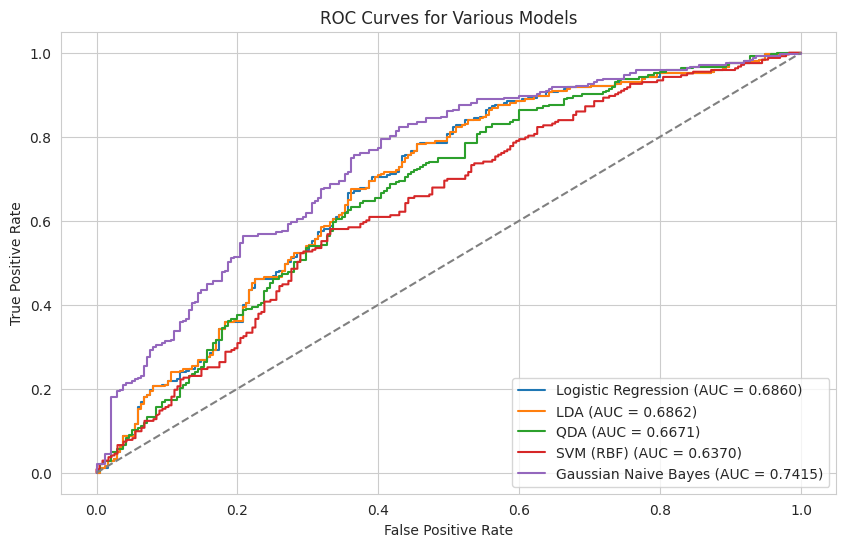

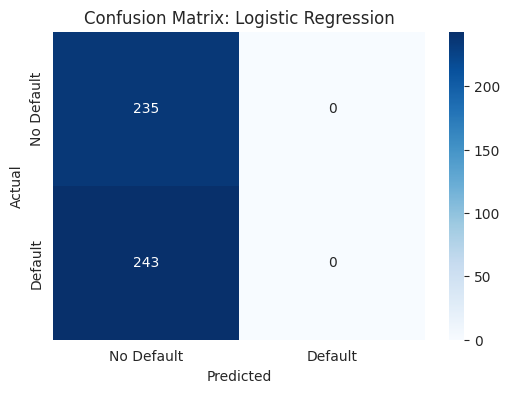

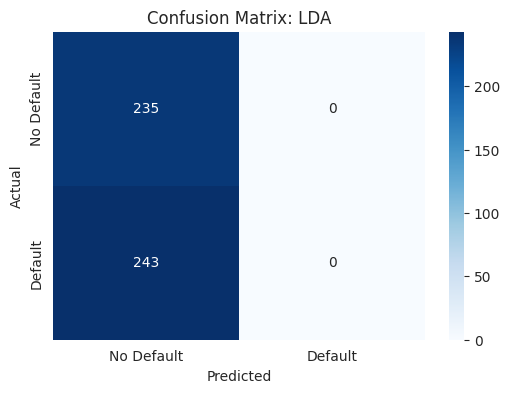

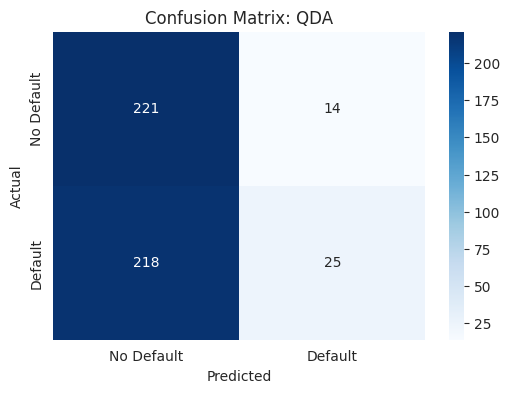

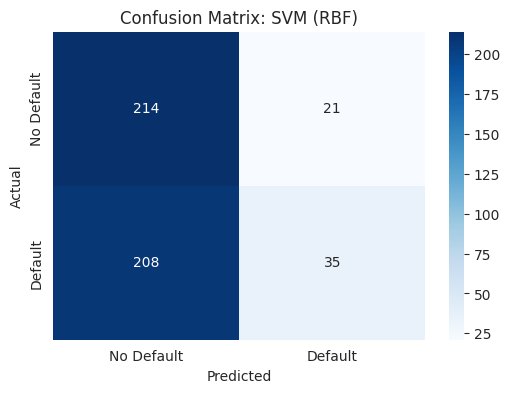

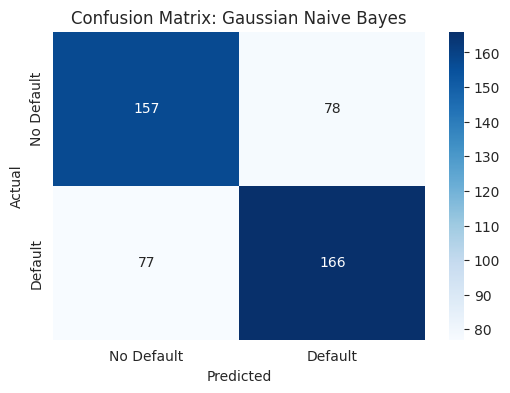


The top-performing model is Gaussian Naive Bayes with an AUC-ROC of 0.7415


In [ ]:
from sklearn.naive_bayes import GaussianNB  # Importing GaussianNB

# Other code...

# Replace CategoricalNB with GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Function to evaluate models
def model_evaluation(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=1)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, precision, recall, f1, auc_score, fpr, tpr, cm

# Models list (replace Categorical Naive Bayes with Gaussian Naive Bayes)
model_list = ["Logistic Regression", "LDA", "QDA", "SVM (RBF)", "Gaussian Naive Bayes"]
model_objects = [log_reg, lda_model, qda_model, svm_rbf, gnb]  # Using gnb here
evaluation_results = []

# Evaluate each model
for name, model in zip(model_list, model_objects):
    accuracy, precision, recall, f1, auc_score, fpr, tpr, cm = model_evaluation(model, X_test, y_test)
    evaluation_results.append([name, accuracy, precision, recall, f1, auc_score, fpr, tpr, cm])

# Create a DataFrame for results
evaluation_df = pd.DataFrame(evaluation_results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'FPR', 'TPR', 'Confusion Matrix'])

# Print evaluation results
print(evaluation_df)

# Plot ROC curves for all models
plt.figure(figsize=(10, 6))
for _, row in evaluation_df.iterrows():
    plt.plot(row['FPR'], row['TPR'], label=f"{row['Model']} (AUC = {row['AUC-ROC']:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Various Models')
plt.legend()
plt.show()

# Display confusion matrices for each model
for _, row in evaluation_df.iterrows():
    plt.figure(figsize=(6, 4))
    sns.heatmap(row['Confusion Matrix'], annot=True, fmt='d', cmap='Blues', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f"Confusion Matrix: {row['Model']}")
    plt.show()

# Identifying the model with the highest AUC-ROC
top_model = evaluation_df.loc[evaluation_df['AUC-ROC'].idxmax()]
print(f"\nThe top-performing model is {top_model['Model']} with an AUC-ROC of {top_model['AUC-ROC']:.4f}")


# Bonus (10 point)
**Implement Hyperparameter Tuning (Grid Search or Randomized Search) for SVM and Logistic Regression.**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Hyperparameter optimization for Logistic Regression
logreg_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Strength of regularization
    'penalty': ['l1', 'l2'],  # Type of regularization
    'solver': ['liblinear']  # Algorithm used for optimization
}

logreg_search = GridSearchCV(LogisticRegression(max_iter=1000), logreg_param_grid, cv=5, scoring='roc_auc')
logreg_search.fit(X_train, y_train)

print("Optimal hyperparameters for Logistic Regression:", logreg_search.best_params_)
print("Best AUC score for Logistic Regression:", logreg_search.best_score_)

# Hyperparameter optimization for SVM with RBF kernel
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf']
}

svm_search = GridSearchCV(SVC(probability=True), svm_param_grid, cv=5, scoring='roc_auc')
svm_search.fit(X_train, y_train)

print("\nOptimal hyperparameters for SVM (RBF kernel):", svm_search.best_params_)
print("Best AUC score for SVM (RBF kernel):", svm_search.best_score_)

# Retrieve the best models
best_logreg_model = logreg_search.best_estimator_
best_svm_model = svm_search.best_estimator_



Optimal hyperparameters for Logistic Regression: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best AUC score for Logistic Regression: 0.6685764345246769

Optimal hyperparameters for SVM (RBF kernel): {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Best AUC score for SVM (RBF kernel): 0.8183892474429129
